# Model Performance Analysis

This notebook summarizes classification results for the fine-tuned catheter models. It reads the generated prediction CSV files, computes accuracy, precision, recall, F1-score, and confusion matrices, then creates tables and figures suitable for manuscript drafts.

Evaluation columns:
- `Original Test`: held-out internal test split from `original`.
- `Original RR`: additional RR evaluation set without hole alignment.
- `HoleAlign Test`: held-out internal test split from `original_holealign`.
- `RR + HoleAlign`: additional RR evaluation set after hole alignment.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["pro1", "pro2", "pro3"]

MODELS = [
    {"model": "ResNet-18", "slug": "resnet18", "input_size": "224 x 224"},
    {"model": "ResNet-50", "slug": "resnet50", "input_size": "224 x 224"},
    {"model": "DenseNet-121", "slug": "densenet121", "input_size": "224 x 224"},
    {"model": "DenseNet-201", "slug": "densenet201", "input_size": "224 x 224"},
    {"model": "EfficientNet-B0", "slug": "efficientnetb0", "input_size": "224 x 224"},
    {"model": "MobileNet-V2", "slug": "mobilenetv2", "input_size": "224 x 224"},
    {"model": "Inception-V3", "slug": "inceptionv3", "input_size": "299 x 299"},
]

EVALUATIONS = [
    {"evaluation": "Original Test", "experiment_suffix": "original_freeze", "csv_name": "test_predictions.csv"},
    {"evaluation": "Original RR", "experiment_suffix": "original_freeze", "csv_name": "original_rr_predictions.csv"},
    {"evaluation": "HoleAlign Test", "experiment_suffix": "original_holealign_freeze", "csv_name": "test_predictions.csv"},
    {"evaluation": "RR + HoleAlign", "experiment_suffix": "original_holealign_freeze", "csv_name": "original_rr_holealign_predictions.csv"},
]

MODEL_ORDER = [item["model"] for item in MODELS]
EVALUATION_ORDER = [item["evaluation"] for item in EVALUATIONS]

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Project root: /home/hjj747/catheter-preprocessing
Outputs will be saved to: /home/hjj747/catheter-preprocessing/notebooks/analysis_outputs


## Load Predictions

`test_predictions.csv` already contains labels. Inference CSV files do not contain labels, so labels are inferred from the parent folder name such as `pro_1`, `pro2_holealign`, etc.

In [2]:
def infer_label_from_path(path_value: str) -> str | None:
    path = str(path_value).replace("\\", "/")
    if "/pro_1/" in path or "/pro1_holealign/" in path:
        return "pro1"
    if "/pro_2/" in path or "/pro2_holealign/" in path:
        return "pro2"
    if "/pro_3/" in path or "/pro3_holealign/" in path:
        return "pro3"
    return None


def load_prediction_csv(csv_path: Path, model_name: str, evaluation_name: str, input_size: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if "label" not in df.columns:
        df["label"] = df["path"].map(infer_label_from_path)
    if "prediction" not in df.columns:
        df["prediction"] = df["top1_class"]
    if df["label"].isna().any():
        missing = df.loc[df["label"].isna(), "path"].head(5).tolist()
        raise ValueError(f"Could not infer labels for {csv_path}: {missing}")
    df["correct"] = (df["label"] == df["prediction"]).astype(int)
    df["model"] = model_name
    df["evaluation"] = evaluation_name
    df["input_size"] = input_size
    df["source_csv"] = str(csv_path.relative_to(PROJECT_ROOT))
    return df


prediction_frames = []
missing_files = []

for model_info in MODELS:
    for eval_info in EVALUATIONS:
        exp_dir = EXPERIMENTS_DIR / f"{model_info['slug']}_{eval_info['experiment_suffix']}"
        csv_path = exp_dir / eval_info["csv_name"]
        if not csv_path.exists():
            missing_files.append(csv_path.relative_to(PROJECT_ROOT))
            continue
        prediction_frames.append(
            load_prediction_csv(
                csv_path=csv_path,
                model_name=model_info["model"],
                evaluation_name=eval_info["evaluation"],
                input_size=model_info["input_size"],
            )
        )

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions["model"] = pd.Categorical(predictions["model"], categories=MODEL_ORDER, ordered=True)
predictions["evaluation"] = pd.Categorical(predictions["evaluation"], categories=EVALUATION_ORDER, ordered=True)

print(f"Loaded prediction rows: {len(predictions):,}")
if missing_files:
    print("Missing result files:")
    for path in missing_files:
        print(f"- {path}")

display(
    predictions.groupby(["model", "evaluation"], observed=True)
    .size()
    .rename("n")
    .reset_index()
    .pivot(index="model", columns="evaluation", values="n")
)


Loaded prediction rows: 2,898


evaluation,Original Test,Original RR,HoleAlign Test,RR + HoleAlign
model,,,,
ResNet-18,27,180,27,180
ResNet-50,27,180,27,180
DenseNet-121,27,180,27,180
DenseNet-201,27,180,27,180
EfficientNet-B0,27,180,27,180
MobileNet-V2,27,180,27,180
Inception-V3,27,180,27,180


## Summary Metrics

This table reports accuracy plus macro/weighted precision, recall, and F1-score. Macro metrics are useful because each class contributes equally.

In [3]:
def compute_summary_metrics(group: pd.DataFrame) -> dict:
    y_true = group["label"].tolist()
    y_pred = group["prediction"].tolist()
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASSES, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASSES, average="weighted", zero_division=0
    )
    return {
        "support": len(group),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }


summary_rows = []
for (model, evaluation), group in predictions.groupby(["model", "evaluation"], observed=True):
    row = {"model": str(model), "evaluation": str(evaluation), "input_size": group["input_size"].iloc[0]}
    row.update(compute_summary_metrics(group))
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary["model"] = pd.Categorical(summary["model"], categories=MODEL_ORDER, ordered=True)
summary["evaluation"] = pd.Categorical(summary["evaluation"], categories=EVALUATION_ORDER, ordered=True)
summary = summary.sort_values(["model", "evaluation"]).reset_index(drop=True)

percent_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"]
summary_display = summary.copy()
for col in percent_cols:
    summary_display[col] = (summary_display[col] * 100).round(2)

summary.to_csv(OUTPUT_DIR / "model_summary_metrics.csv", index=False)
summary_display.to_csv(OUTPUT_DIR / "model_summary_metrics_percent.csv", index=False)
display(summary_display)


,model,evaluation,input_size,support,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,ResNet-18,Original Test,224 x 224,27,88.89,91.67,88.89,88.57,91.67,88.89,88.57
1,ResNet-18,Original RR,224 x 224,180,85.56,86.50,85.56,85.25,86.50,85.56,85.25
2,ResNet-18,HoleAlign Test,224 x 224,27,100.00,100.00,100.00,100.00,100.00,100.00,100.00
3,ResNet-18,RR + HoleAlign,224 x 224,180,98.33,98.34,98.33,98.33,98.34,98.33,98.33
4,ResNet-50,Original Test,224 x 224,27,96.30,96.67,96.30,96.28,96.67,96.30,96.28
5,ResNet-50,Original RR,224 x 224,180,97.78,97.87,97.78,97.76,97.87,97.78,97.76
6,ResNet-50,HoleAlign Test,224 x 224,27,100.00,100.00,100.00,100.00,100.00,100.00,100.00
7,ResNet-50,RR + HoleAlign,224 x 224,180,100.00,100.00,100.00,100.00,100.00,100.00,100.00
8,DenseNet-121,Original Test,224 x 224,27,100.00,100.00,100.00,100.00,100.00,100.00,100.00
9,DenseNet-121,Original RR,224 x 224,180,89.44,89.83,89.44,89.23,89.83,89.44,89.23


## Manuscript-Style Accuracy Table

This compact table mirrors common image-classification result tables. Use `Original Test`, `Original RR`, and `RR + HoleAlign` as the main columns if the paper focuses on robustness and preprocessing effects.

In [4]:
accuracy_table = (
    summary.assign(accuracy_percent=lambda df: df["accuracy"] * 100)
    .pivot(index=["model", "input_size"], columns="evaluation", values="accuracy_percent")
    .reset_index()
)
accuracy_table["model"] = pd.Categorical(accuracy_table["model"], categories=MODEL_ORDER, ordered=True)
accuracy_table = accuracy_table.sort_values("model")

paper_columns = ["model", "input_size", "Original Test", "Original RR", "RR + HoleAlign"]
paper_table = accuracy_table[paper_columns].copy()
for col in paper_columns[2:]:
    paper_table[col] = paper_table[col].map(lambda value: f"{value:.2f}%")

paper_table.to_csv(OUTPUT_DIR / "paper_accuracy_table.csv", index=False)
display(paper_table)


evaluation,model,input_size,Original Test,Original RR,RR + HoleAlign
0,ResNet-18,224 x 224,88.89%,85.56%,98.33%
1,ResNet-50,224 x 224,96.30%,97.78%,100.00%
2,DenseNet-121,224 x 224,100.00%,89.44%,100.00%
3,DenseNet-201,224 x 224,100.00%,82.78%,99.44%
4,EfficientNet-B0,224 x 224,100.00%,94.44%,100.00%
5,MobileNet-V2,224 x 224,100.00%,98.33%,97.22%
6,Inception-V3,299 x 299,100.00%,53.89%,100.00%


## Per-Class Metrics

Per-class precision, recall, and F1-score help identify which process class is unstable. This is especially important when overall accuracy is high.

In [5]:
per_class_rows = []
for (model, evaluation), group in predictions.groupby(["model", "evaluation"], observed=True):
    precision, recall, f1, support = precision_recall_fscore_support(
        group["label"], group["prediction"], labels=CLASSES, average=None, zero_division=0
    )
    for class_name, p, r, f, s in zip(CLASSES, precision, recall, f1, support):
        per_class_rows.append(
            {
                "model": str(model),
                "evaluation": str(evaluation),
                "class": class_name,
                "precision": p,
                "recall": r,
                "f1": f,
                "support": int(s),
            }
        )

per_class = pd.DataFrame(per_class_rows)
per_class["model"] = pd.Categorical(per_class["model"], categories=MODEL_ORDER, ordered=True)
per_class["evaluation"] = pd.Categorical(per_class["evaluation"], categories=EVALUATION_ORDER, ordered=True)
per_class.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)

per_class_display = per_class.copy()
for col in ["precision", "recall", "f1"]:
    per_class_display[col] = (per_class_display[col] * 100).round(2)

display(per_class_display.sort_values(["evaluation", "model", "class"]))


,model,evaluation,class,precision,recall,f1,support
0,ResNet-18,Original Test,pro1,100.00,100.00,100.00,9
1,ResNet-18,Original Test,pro2,100.00,66.67,80.00,9
2,ResNet-18,Original Test,pro3,75.00,100.00,85.71,9
12,ResNet-50,Original Test,pro1,100.00,100.00,100.00,9
13,ResNet-50,Original Test,pro2,100.00,88.89,94.12,9
...,...,...,...,...,...,...,...
70,MobileNet-V2,RR + HoleAlign,pro2,96.77,100.00,98.36,60
71,MobileNet-V2,RR + HoleAlign,pro3,100.00,91.67,95.65,60
81,Inception-V3,RR + HoleAlign,pro1,100.00,100.00,100.00,60
82,Inception-V3,RR + HoleAlign,pro2,100.00,100.00,100.00,60


## Accuracy Heatmap

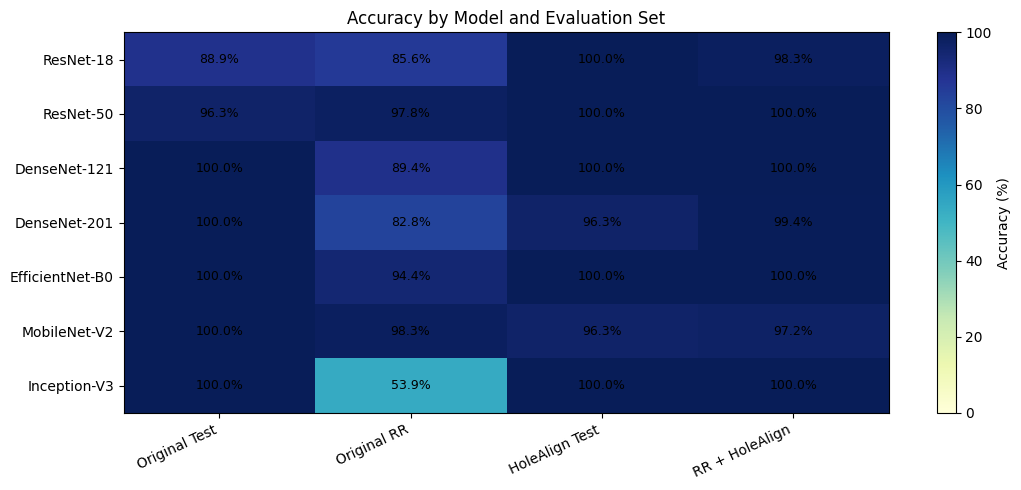

In [6]:
heatmap_data = (
    summary.assign(accuracy_percent=lambda df: df["accuracy"] * 100)
    .pivot(index="model", columns="evaluation", values="accuracy_percent")
    .reindex(index=MODEL_ORDER, columns=EVALUATION_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 5))
image = ax.imshow(heatmap_data.values, cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=25, ha="right")
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for row_idx in range(heatmap_data.shape[0]):
    for col_idx in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f"{value:.1f}%", ha="center", va="center", fontsize=9)
ax.set_title("Accuracy by Model and Evaluation Set")
fig.colorbar(image, ax=ax, label="Accuracy (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "accuracy_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Macro F1 Comparison

The RR sets usually reveal model differences more clearly than the small internal test split.

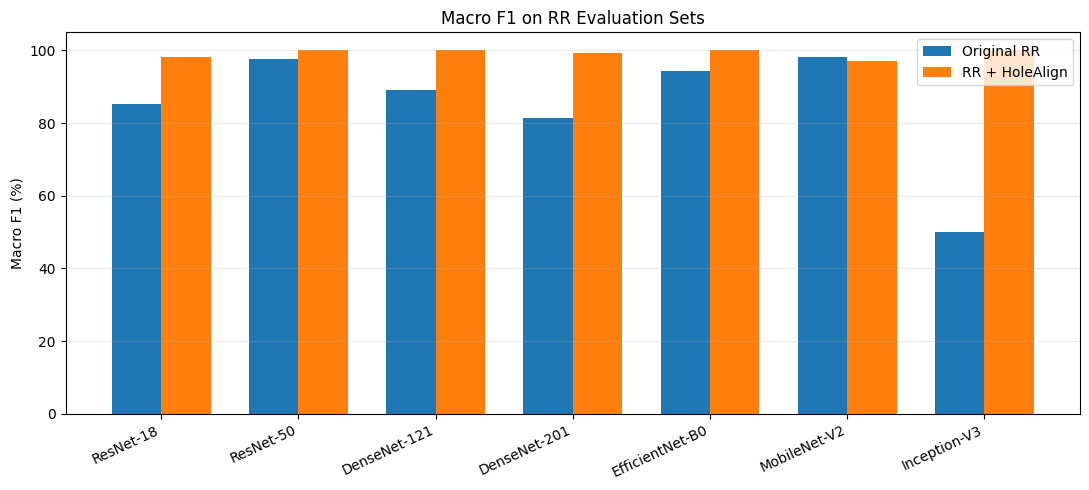

In [7]:
f1_data = (
    summary[summary["evaluation"].isin(["Original RR", "RR + HoleAlign"])]
    .assign(macro_f1_percent=lambda df: df["macro_f1"] * 100)
    .pivot(index="model", columns="evaluation", values="macro_f1_percent")
    .reindex(index=MODEL_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(f1_data.index))
width = 0.36
ax.bar(x - width / 2, f1_data["Original RR"], width=width, label="Original RR")
ax.bar(x + width / 2, f1_data["RR + HoleAlign"], width=width, label="RR + HoleAlign")
ax.set_xticks(x)
ax.set_xticklabels(f1_data.index, rotation=25, ha="right")
ax.set_ylabel("Macro F1 (%)")
ax.set_ylim(0, 105)
ax.set_title("Macro F1 on RR Evaluation Sets")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rr_macro_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## Per-Class F1 on Original RR

This figure highlights which class drives the errors before hole alignment.

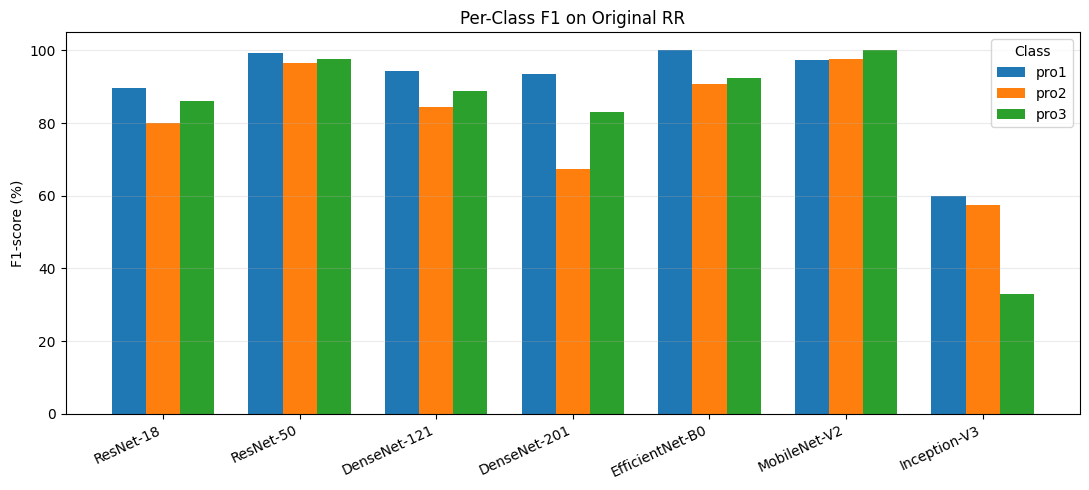

In [8]:
rr_f1 = (
    per_class[per_class["evaluation"] == "Original RR"]
    .assign(f1_percent=lambda df: df["f1"] * 100)
    .pivot(index="model", columns="class", values="f1_percent")
    .reindex(index=MODEL_ORDER, columns=CLASSES)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rr_f1.index))
width = 0.25
for idx, class_name in enumerate(CLASSES):
    ax.bar(x + (idx - 1) * width, rr_f1[class_name], width=width, label=class_name)
ax.set_xticks(x)
ax.set_xticklabels(rr_f1.index, rotation=25, ha="right")
ax.set_ylabel("F1-score (%)")
ax.set_ylim(0, 105)
ax.set_title("Per-Class F1 on Original RR")
ax.legend(title="Class")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "original_rr_per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()


## Confusion Matrices

The next cell saves confusion-matrix figures for all models on `Original RR` and `RR + HoleAlign`.

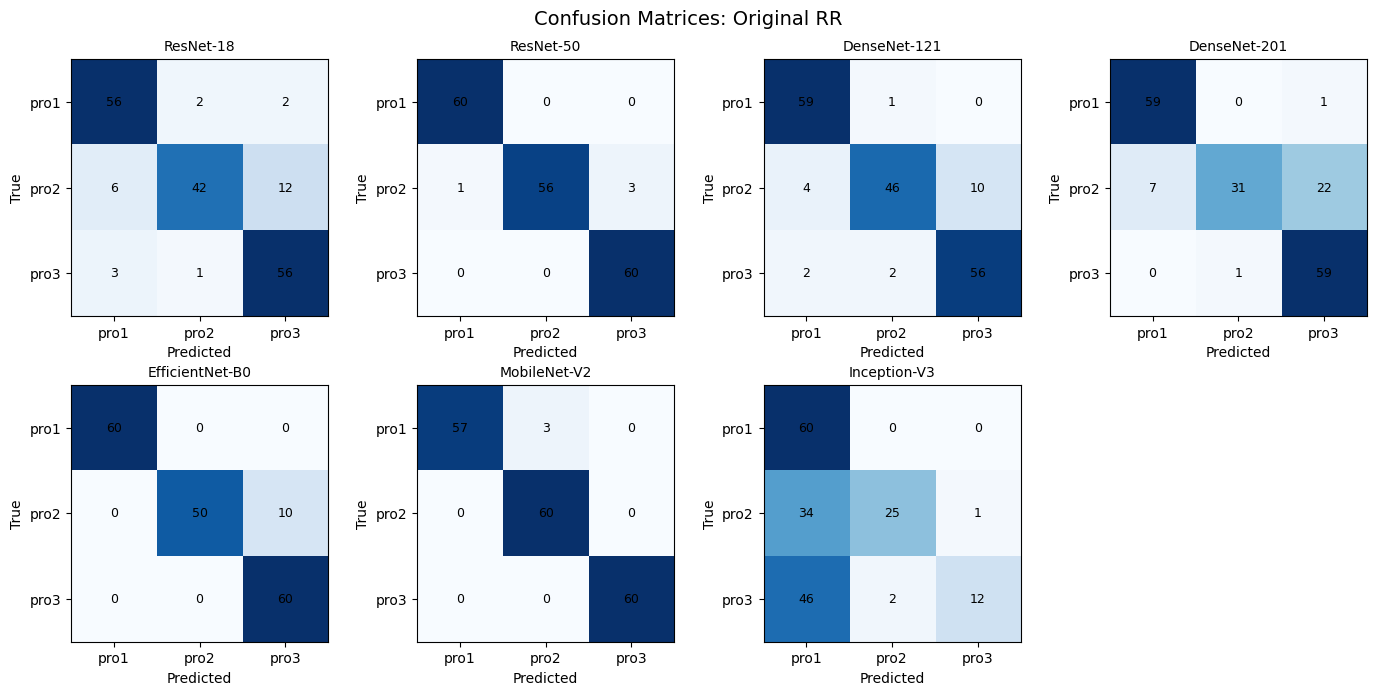

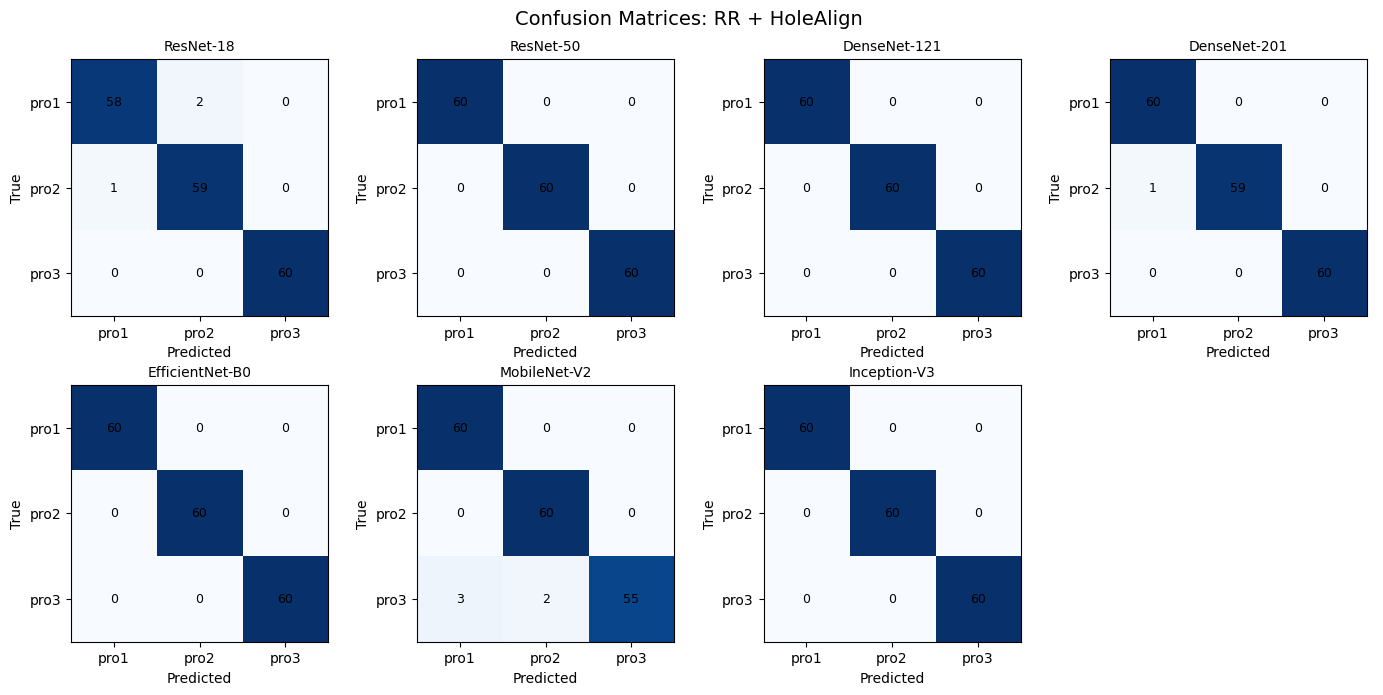

In [9]:
def plot_confusion_matrix(ax, matrix: np.ndarray, title: str):
    image = ax.imshow(matrix, cmap="Blues", vmin=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(len(CLASSES)))
    ax.set_xticklabels(CLASSES)
    ax.set_yticks(np.arange(len(CLASSES)))
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center", color="black", fontsize=9)
    return image


for evaluation_name in ["Original RR", "RR + HoleAlign"]:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for ax, model_name in zip(axes, MODEL_ORDER):
        group = predictions[(predictions["model"] == model_name) & (predictions["evaluation"] == evaluation_name)]
        matrix = confusion_matrix(group["label"], group["prediction"], labels=CLASSES)
        plot_confusion_matrix(ax, matrix, model_name)
    for ax in axes[len(MODEL_ORDER):]:
        ax.axis("off")
    fig.suptitle(f"Confusion Matrices: {evaluation_name}", fontsize=14)
    fig.tight_layout()
    safe_name = evaluation_name.lower().replace(" ", "_").replace("+", "plus")
    fig.savefig(OUTPUT_DIR / f"confusion_matrices_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


## Error List

This table lists misclassified samples. It is useful for qualitative inspection and for identifying repeated difficult cases.

In [10]:
error_columns = ["model", "evaluation", "path", "label", "prediction"]
probability_columns = [col for col in ["top1_probability", "top2_class", "top2_probability"] if col in predictions.columns]
errors = predictions[predictions["correct"] == 0][error_columns + probability_columns].copy()
errors.to_csv(OUTPUT_DIR / "misclassified_samples.csv", index=False)
display(errors.sort_values(["evaluation", "model", "label", "path"]))

print("Saved files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.relative_to(PROJECT_ROOT)}")


,model,evaluation,path,label,prediction,top1_probability,top2_class,top2_probability
5,ResNet-18,Original Test,/home/hjj747/catheter-preprocessing/data/datas...,pro2,pro3,NaN,NaN,NaN
8,ResNet-18,Original Test,/home/hjj747/catheter-preprocessing/data/datas...,pro2,pro3,NaN,NaN,NaN
4,ResNet-18,Original Test,/home/hjj747/catheter-preprocessing/data/datas...,pro2,pro3,NaN,NaN,NaN
426,ResNet-50,Original Test,/home/hjj747/catheter-preprocessing/data/datas...,pro2,pro3,NaN,NaN,NaN
44,ResNet-18,Original RR,data/dataset/original_rr/pro_1/2_s20_4.BMP,pro1,pro3,0.356760,pro2,0.343228
...,...,...,...,...,...,...,...,...
2432,MobileNet-V2,RR + HoleAlign,data/dataset/original_rr_holealign/pro3_holeal...,pro3,pro1,0.365243,pro3,0.348685
2442,MobileNet-V2,RR + HoleAlign,data/dataset/original_rr_holealign/pro3_holeal...,pro3,pro2,0.357940,pro1,0.339889
2449,MobileNet-V2,RR + HoleAlign,data/dataset/original_rr_holealign/pro3_holeal...,pro3,pro1,0.431065,pro3,0.370168
2458,MobileNet-V2,RR + HoleAlign,data/dataset/original_rr_holealign/pro3_holeal...,pro3,pro2,0.385044,pro3,0.356777


Saved files:
- notebooks/analysis_outputs/accuracy_heatmap.png
- notebooks/analysis_outputs/confusion_matrices_original_rr.png
- notebooks/analysis_outputs/confusion_matrices_rr_plus_holealign.png
- notebooks/analysis_outputs/misclassified_samples.csv
- notebooks/analysis_outputs/model_summary_metrics.csv
- notebooks/analysis_outputs/model_summary_metrics_percent.csv
- notebooks/analysis_outputs/original_rr_per_class_f1.png
- notebooks/analysis_outputs/paper_accuracy_table.csv
- notebooks/analysis_outputs/per_class_metrics.csv
- notebooks/analysis_outputs/rr_macro_f1_comparison.png
